# Resilient distributed training

Start a fresh kernel, then Run all: the first cell configures 4 logical CPU devices before backend initialization so you can practice multi-device sharding locally.

- Restore a complete training state with explicit target sharding.
- Compare next sample IDs, optimizer state and losses across an epoch boundary.
- Explain single-controller evidence and the additional requirements of a real multi-controller restart.

A restarted sharded run loads the right weights, yet its next update differs. Which missing state could explain that? We will checkpoint a real sharded training step, restore its parameters, momentum, random key and data position, then compare three subsequent updates across an epoch boundary.

## The idea

Distributed recovery must reconstruct a consistent global state. Participants cannot independently load arbitrary local snapshots and assume the pieces describe one completed update. Checkpoint identity and step meaning must agree.

## Agree on one global recovery boundary

Two local files from different steps can each load successfully while forming no valid global checkpoint. A shared manifest should identify which pieces belong together and what happens if a required piece is missing.

After restore, compare the next global computation with an uninterrupted reference, including input position and random-state ownership. Silent partial recovery changes the computation instead of continuing it.

The CPU replay checks this bounded fixture's continuation. It is separate from multi-host failure handling, storage durability or accelerator networking. Those require additional operational evidence when deploying the design.

### Pause and reason

Why is successful loading on every worker insufficient?

<details><summary>Compare your reasoning</summary>

Workers may load incompatible steps or pieces. Correct recovery requires one consistent global identity and the intended next computation.

</details>

## Name the values that determine the next transition

The state contains weights $w$, momentum $v$, a random key, the current example permutation, the cursor into that permutation and the completed step. A batch is selected from the saved order, then a global mean gradient updates momentum and weights. After the final batch in an epoch, a new split key creates the next order. Saving only the current permutation can therefore reproduce the first resumed batch but fail at the next epoch.

$$
v_{t+1}=0.8v_t+\nabla L_t(w_t),\qquad w_{t+1}=w_t-0.04v_{t+1}
$$

## Checkpoint one completed global step

The example partitions examples across four logical CPU devices and keeps its small parameter state replicated. It waits for the step loss, saves the entire state with a real Orbax StandardCheckpointer, waits for saving to finish and restores against a target whose arrays carry the intended mesh and sharding. Every restored leaf is compared with the saved snapshot.

The dataset is a deterministic tiny NumPy fixture. Every controller can reconstruct it from the same declared seed, dimensions and target rule. Real input systems need data identity, preprocessing configuration and iterator recovery, as covered in the recovery phase; matching a seed alone is not enough for a changing dataset. Changing the number of devices here changes fixture dimensions and is deliberately outside this restart contract.

## Prove the next updates, including the next epoch

After restoring step one, run the uninterrupted and resumed states through three transitions. Compare sample IDs before comparing losses. Then compare every state leaf after each transition. The first resumed batch finishes the existing epoch, and the next transition draws a new permutation; this exercises saved random state as well as the current data cursor.

Each update also checks the global gradient with a separate NumPy formula. Agreement between two runs would not detect an identical bug in both runs. Independent arithmetic establishes the update; replay establishes the restore boundary. Float32 reduction order can vary, so numerical arrays use a stated tolerance while sample order must match exactly.

To check a real new process on CPU, save the assembled program as main.py, run it once and copy the printed checkpoint parent folder. Run `COURSE_RESUME=1 COURSE_CHECKPOINT_DIR=/your/printed/folder python main.py` from a new terminal process. This loads the existing file; it does not save a replacement. An incorrect path is rejected. Keep both reports.

## Move the protocol to multiple controllers explicitly

The default run has one controller and four logical CPU devices. It does not kill a worker or test cross-host storage failure. The optional COURSE_MULTIPROCESS branch calls jax.distributed.initialize before any device query and builds a global mesh. Every controller must run the same script, take the same branches and call save and restore in the same order. The tiny fixture is intentionally duplicated on each host; the callback supplies only the slices required by each addressable shard.

On a supported existing multi-host TPU environment, give every worker the same new shared checkpoint directory and run the command below on every worker. The launcher must supply the environment that JAX uses for initialization. A path local to only one worker is not shared storage. For a fresh-process restart of this drill, run every controller again with COURSE_RESUME=1 and the same checkpoint directory. Resume skips saving and restores the existing accepted step-one snapshot; the script recomputes the deterministic step-one baseline only to verify this teaching fixture. A general training job must select and validate its own accepted step. Restart the whole worker group according to your job manager; this lesson does not implement elastic membership or automatic worker replacement. This target branch is executable but has not been run on a multi-host cluster here.

**Distribute the script and launch across every worker of a multi-host TPU slice**

```bash
# Distribute the script and launch across every worker of a multi-host TPU slice
gcloud compute tpus tpu-vm scp exercises/distributed-04.py $TPU_NAME:~/jax-tpu-lab/ --zone=$ZONE --worker=all
gcloud compute tpus tpu-vm ssh $TPU_NAME --zone=$ZONE --worker=all \
  --command="COURSE_MULTIPROCESS=1 JAX_PLATFORMS=tpu COURSE_CHECKPOINT_DIR=/shared/new-recovery-run ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/distributed-04.py"
```

**Expected:** All workers initialize distributed JAX, coordinate, save and restore through the same shared path, and report tpu with a process count greater than one. This command needs a configured multi-host TPU slice and shared storage.

**Resume the same accepted checkpoint across every TPU slice worker**

```bash
# Resume the same accepted checkpoint across every TPU slice worker
gcloud compute tpus tpu-vm ssh $TPU_NAME --zone=$ZONE --worker=all \
  --command="COURSE_MULTIPROCESS=1 COURSE_RESUME=1 JAX_PLATFORMS=tpu COURSE_CHECKPOINT_DIR=/shared/new-recovery-run ~/jax-tpu-lab/.venv/bin/python ~/jax-tpu-lab/distributed-04.py"
```

**Expected:** The worker group loads its existing step-one checkpoint without overwriting it, then verifies subsequent updates across the epoch boundary.

## Reject an inconsistent recovery point

An existing checkpoint directory is rejected to avoid overwriting evidence from a previous experiment. Use a new directory for each drill. In a production system, the accepted checkpoint also needs a matching code/configuration version and data manifest. A readable checkpoint with the wrong schema, data stream or step counter must not become a successful recovery report.

The controlled failures below replace only momentum or only the random key. The first changes the very next update; the second can remain hidden until an epoch transition. These are fault-injected restore experiments, not claims that a live multi-host process failure was tested. The operations project separately exercises real local worker termination and a restart runbook.

## Initialize the runtime before device access

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [1]:
# Step 1 — Initialize the runtime before device access: Every controller must use consistent state, data and collective...
# Import os for this computation.
import os
import tempfile
from pathlib import Path
import jax
# Read `multi` from environment configuration (with a default fallback).
multi = os.environ.get('COURSE_MULTIPROCESS') == '1'
# Read `resume` from environment configuration (with a default fallback).
resume = os.environ.get('COURSE_RESUME') == '1'
# Branch on condition `multi`:
if multi:
    # Every controller runs this before querying devices or creating arrays.
    jax.distributed.initialize()
else:
    jax.config.update('jax_platforms', 'cpu')
    jax.config.update('jax_num_cpu_devices', 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import orbax.checkpoint as ocp
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Define the global fixture and placements

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [2]:
# Step 2 — Define the global fixture and placements: Every controller must use consistent state, data and collective...
count = jax.device_count()
# Assert invariant `count >= 2` holds
assert count >= 2, 'Use at least two devices for the placement exercise'
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.asarray(jax.devices()), ('data',))
# Configure multi-device placement / sharding specification (`rep`).
rep = NamedSharding(mesh, P())
# Configure multi-device placement / sharding specification (`row`).
row = NamedSharding(mesh, P('data', None))
# Configure multi-device placement / sharding specification (`label`).
label = NamedSharding(mesh, P('data'))
# Compute `batch_size, size, width` from `2 * count, 4 * count, 2 * count`
batch_size, size, width = 2 * count, 4 * count, 2 * count
# Identical tiny synthetic fixture on each controller; not distributed data ingestion.
data = np.random.default_rng(41).normal(size=(size, width)).astype(np.float32)
# Compute `truth` from `np.linspace(-0.3, 0.4, width, dtype=np.float32)`
truth = np.linspace(-0.3, 0.4, width, dtype=np.float32)
# Perform matrix / vector contraction (`@`) to compute `targets`.
targets = data @ truth

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Carry complete transition state

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [3]:
# Step 3 — Carry complete transition state: Every controller must use consistent state, data and collective...
def placed(value, sharding=rep):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(value)
    # Return `jax.make_array_from_callback(a.shape, sharding, lambda index: a[index])` to the caller.
    return jax.make_array_from_callback(a.shape, sharding, lambda index: a[index])

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Checkpoint and verify replay

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [4]:
# Step 4 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
def initial():
    # Create or split explicit PRNG key(s) (`(key, order_key)`) for reproducible randomness.
    key, order_key = jax.random.split(jax.random.PRNGKey(17))
    # Return `{'weights': placed(np.zeros(width, np.float32)), 'momentum': placed(np.zeros(width, np.float32)), 'key': placed(np.asarray(key)), 'order': placed(np.asarray(jax.random.permutation(order_key, size))), 'cursor': placed(np.int32(0)), 'step': placed(np.int32(0))}` to the caller.
    return { 'weights': placed(np.zeros(width, np.float32)),
             'momentum': placed(np.zeros(width, np.float32)),
             'key': placed(np.asarray(key)),
             'order': placed(np.asarray(jax.random.permutation(order_key, size))),
             'cursor': placed(np.int32(0)), 'step': placed(np.int32(0)) }

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Checkpoint and verify replay

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [5]:
# Step 5 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
# Define and JIT-compile `update(w, velocity, x, y)` so XLA traces and fuses the operations:
@jax.jit
# Function `update(w, velocity, x, y)` implementing this stage's computation:
def update(w, velocity, x, y):
    # Differentiate the objective to obtain `(loss, grad)` via automatic differentiation.
    loss, grad = jax.value_and_grad(lambda a: jnp.mean((x @ a - y)**2))(w)
    # Compute `v` from `0.8 * velocity + grad`
    v = 0.8 * velocity + grad
    # Return `(w - 0.04 * v, v, loss)` to the caller.
    return w - 0.04 * v, v, loss

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Checkpoint and verify replay

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [6]:
# Step 6 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
def transition(state):
    # Evaluate `state['cursor']` and convert the result into Python scalar/collection `cursor`.
    cursor = int(state['cursor'])
    # Convert `order` to a host NumPy array for inspection or verification.
    order = np.asarray(state['order'])
    # Compute `key` from `state['key']`
    key = state['key']
    # Branch on condition `cursor == size`:
    if cursor == size:
        key, shuffle_key = jax.random.split(key)
        order = np.asarray(jax.random.permutation(shuffle_key, size))
        cursor = 0
    # Compute `ids` from `order[cursor:cursor + batch_size]`
    ids = order[cursor:cursor + batch_size]
    # Compute `x, y` from `placed(data[ids], row), placed(targets[ids], label)`
    x, y = placed(data[ids], row), placed(targets[ids], label)
    # Run `update` to compute `(w, v, loss)`.
    w, v, loss = update(state['weights'], state['momentum'], x, y)
    # Synchronize host execution until asynchronous device computation completes.
    loss.block_until_ready()
    # Independent global derivative and momentum update on the host.
    old_w, old_v = np.asarray(state['weights']), np.asarray(state['momentum'])
    # Perform matrix contraction / projection to compute `g`.
    g = 2 * data[ids].T @ (data[ids] @ old_w - targets[ids]) / batch_size
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(v), 0.8 * old_v + g, rtol=2e-5, atol=2e-6)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(w), old_w - 0.04 * np.asarray(v), rtol=2e-5, atol=2e-6)
    # Convert `new` to a host NumPy array for inspection or verification.
    new = dict(weights=w, momentum=v, key=placed(np.asarray(key)),
               order=placed(order), cursor=placed(np.int32(cursor+batch_size)),
               step=placed(np.int32(int(state['step'])+1)))
    # Return `(new, ids.copy(), float(loss))` to the caller.
    return new, ids.copy(), float(loss)

Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Checkpoint and verify replay

Add this block after the preceding block in main.py and run the assembled file in a fresh process.

In [7]:
# Step 7 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
state = initial()
# Run `transition` to compute `(state, first_ids, _)`.
state, first_ids, _ = transition(state)
# Shared path is mandatory for real multi-controller execution.
if multi:
    root = Path(os.environ['COURSE_CHECKPOINT_DIR']).resolve()
else:
    root = Path(os.environ['COURSE_CHECKPOINT_DIR']).resolve() if os.environ.get('COURSE_CHECKPOINT_DIR') else Path(tempfile.mkdtemp(prefix='jax-distributed-recovery-'))
# Compute `checkpoint_path` from `root / 'step-one'`
checkpoint_path = root / 'step-one'
# Guard input contract (`resume and (not checkpoint_path.exists())`) and fail fast if violated.
if resume and not checkpoint_path.exists():
    raise FileNotFoundError('Resume needs an existing step-one checkpoint')
# Guard input contract (`not resume and checkpoint_path.exists()`) and fail fast if violated.
if not resume and checkpoint_path.exists():
    raise FileExistsError('Use a new folder or set COURSE_RESUME=1 for the accepted checkpoint')
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as checkpointer:
    # Branch on condition `not resume`:
    if not resume:
        checkpointer.save(checkpoint_path, state)
        checkpointer.wait_until_finished()
    # Target carries the current mesh/sharding, rather than inferring it from old metadata.
    restored = checkpointer.restore(checkpoint_path, target=initial())
    # Iterate over `name` to step through the computation:
    for name in state:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(restored[name]), np.asarray(state[name]))
    # Compute `baseline, resumed` from `state, restored`
    baseline, resumed = state, restored
    # Compute `baseline_losses, resumed_losses, replay_ids` from `[], [], []`
    baseline_losses, resumed_losses, replay_ids = [], [], []
    # Repeat the update loop over `range(3)` steps:
    for _ in range(3):
        # Run `transition` to compute `(baseline, ids_a, loss_a)`.
        baseline, ids_a, loss_a = transition(baseline)
        # Run `transition` to compute `(resumed, ids_b, loss_b)`.
        resumed, ids_b, loss_b = transition(resumed)
        # Execute `np.testing.assert_array_equal(ids_a, ids_b)`
        np.testing.assert_array_equal(ids_a, ids_b)
        # Loop over `name` in `baseline`:
        for name in baseline:
            # Convert `` to a host NumPy array for inspection or verification.
            np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol=2e-5, atol=2e-6)
        # Append the current step result to `baseline_losses`.
        baseline_losses.append(loss_a)
        # Append the current step result to `resumed_losses`.
        resumed_losses.append(loss_b)
        # Append the current step result to `replay_ids`.
        replay_ids.append(ids_a.tolist())
# Print the observed values to compare against the expected result.
print('Recorded backend/processes/devices:', jax.default_backend(), jax.process_count(), count)
# Print diagnostic summary of the computed outputs.
print('Restored step/cursor:', int(restored['step']), int(restored['cursor']))
# Print diagnostic summary of the computed outputs.
print('Next sample IDs across epoch boundary:', replay_ids)
# Print diagnostic summary of the computed outputs.
print('Uninterrupted losses:', baseline_losses)
# Print diagnostic summary of the computed outputs.
print('Restored losses:', resumed_losses)
# Print diagnostic summary of the computed outputs.
print('Checkpoint:', checkpoint_path)

Recorded backend/processes/devices: cpu 1 4
Restored step/cursor: 1 8
Next sample IDs across epoch boundary: [[12, 5, 4, 1, 8, 13, 2, 11], [9, 0, 7, 15, 11, 13, 8, 14], [1, 6, 5, 4, 3, 12, 2, 10]]
Uninterrupted losses: [0.5069587826728821, 0.19637340307235718, 0.1798383891582489]
Restored losses: [0.5069587826728821, 0.19637340307235718, 0.1798383891582489]
Checkpoint: /var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-distributed-recovery-gojce0a8/step-one


Every controller must use consistent state, data and collective order; the default exercise runs on four logical CPU devices.

## Run the example

In [8]:
# Step 1 — Initialize the runtime before device access: Every controller must use consistent state, data and collective...
# Import os for this computation.
import os
import tempfile
from pathlib import Path
import jax
# Read `multi` from environment configuration (with a default fallback).
multi = os.environ.get('COURSE_MULTIPROCESS') == '1'
# Read `resume` from environment configuration (with a default fallback).
resume = os.environ.get('COURSE_RESUME') == '1'
# Branch on condition `multi`:
if multi:
    # Every controller runs this before querying devices or creating arrays.
    jax.distributed.initialize()
else:
    jax.config.update('jax_platforms', 'cpu')
    jax.config.update('jax_num_cpu_devices', 4)
# Import jax.numpy for this computation.
import jax.numpy as jnp
import numpy as np
import orbax.checkpoint as ocp
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P

# Step 2 — Define the global fixture and placements: Every controller must use consistent state, data and collective...
count = jax.device_count()
# Assert invariant `count >= 2` holds
assert count >= 2, 'Use at least two devices for the placement exercise'
# Configure multi-device placement / sharding specification (`mesh`).
mesh = Mesh(np.asarray(jax.devices()), ('data',))
# Configure multi-device placement / sharding specification (`rep`).
rep = NamedSharding(mesh, P())
# Configure multi-device placement / sharding specification (`row`).
row = NamedSharding(mesh, P('data', None))
# Configure multi-device placement / sharding specification (`label`).
label = NamedSharding(mesh, P('data'))
# Compute `batch_size, size, width` from `2 * count, 4 * count, 2 * count`
batch_size, size, width = 2 * count, 4 * count, 2 * count
# Identical tiny synthetic fixture on each controller; not distributed data ingestion.
data = np.random.default_rng(41).normal(size=(size, width)).astype(np.float32)
# Compute `truth` from `np.linspace(-0.3, 0.4, width, dtype=np.float32)`
truth = np.linspace(-0.3, 0.4, width, dtype=np.float32)
# Perform matrix / vector contraction (`@`) to compute `targets`.
targets = data @ truth

# Step 3 — Carry complete transition state: Every controller must use consistent state, data and collective...
def placed(value, sharding=rep):
    # Convert `a` to a host NumPy array for inspection or verification.
    a = np.asarray(value)
    # Return `jax.make_array_from_callback(a.shape, sharding, lambda index: a[index])` to the caller.
    return jax.make_array_from_callback(a.shape, sharding, lambda index: a[index])

# Step 4 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
def initial():
    # Create or split explicit PRNG key(s) (`(key, order_key)`) for reproducible randomness.
    key, order_key = jax.random.split(jax.random.PRNGKey(17))
    # Return `{'weights': placed(np.zeros(width, np.float32)), 'momentum': placed(np.zeros(width, np.float32)), 'key': placed(np.asarray(key)), 'order': placed(np.asarray(jax.random.permutation(order_key, size))), 'cursor': placed(np.int32(0)), 'step': placed(np.int32(0))}` to the caller.
    return { 'weights': placed(np.zeros(width, np.float32)),
             'momentum': placed(np.zeros(width, np.float32)),
             'key': placed(np.asarray(key)),
             'order': placed(np.asarray(jax.random.permutation(order_key, size))),
             'cursor': placed(np.int32(0)), 'step': placed(np.int32(0)) }

# Step 5 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
# Define and JIT-compile `update(w, velocity, x, y)` so XLA traces and fuses the operations:
@jax.jit
# Function `update(w, velocity, x, y)` implementing this stage's computation:
def update(w, velocity, x, y):
    # Differentiate the objective to obtain `(loss, grad)` via automatic differentiation.
    loss, grad = jax.value_and_grad(lambda a: jnp.mean((x @ a - y)**2))(w)
    # Compute `v` from `0.8 * velocity + grad`
    v = 0.8 * velocity + grad
    # Return `(w - 0.04 * v, v, loss)` to the caller.
    return w - 0.04 * v, v, loss

# Step 6 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
def transition(state):
    # Evaluate `state['cursor']` and convert the result into Python scalar/collection `cursor`.
    cursor = int(state['cursor'])
    # Convert `order` to a host NumPy array for inspection or verification.
    order = np.asarray(state['order'])
    # Compute `key` from `state['key']`
    key = state['key']
    # Branch on condition `cursor == size`:
    if cursor == size:
        key, shuffle_key = jax.random.split(key)
        order = np.asarray(jax.random.permutation(shuffle_key, size))
        cursor = 0
    # Compute `ids` from `order[cursor:cursor + batch_size]`
    ids = order[cursor:cursor + batch_size]
    # Compute `x, y` from `placed(data[ids], row), placed(targets[ids], label)`
    x, y = placed(data[ids], row), placed(targets[ids], label)
    # Run `update` to compute `(w, v, loss)`.
    w, v, loss = update(state['weights'], state['momentum'], x, y)
    # Synchronize host execution until asynchronous device computation completes.
    loss.block_until_ready()
    # Independent global derivative and momentum update on the host.
    old_w, old_v = np.asarray(state['weights']), np.asarray(state['momentum'])
    # Perform matrix contraction / projection to compute `g`.
    g = 2 * data[ids].T @ (data[ids] @ old_w - targets[ids]) / batch_size
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(v), 0.8 * old_v + g, rtol=2e-5, atol=2e-6)
    # Convert `` to a host NumPy array for inspection or verification.
    np.testing.assert_allclose(np.asarray(w), old_w - 0.04 * np.asarray(v), rtol=2e-5, atol=2e-6)
    # Convert `new` to a host NumPy array for inspection or verification.
    new = dict(weights=w, momentum=v, key=placed(np.asarray(key)),
               order=placed(order), cursor=placed(np.int32(cursor+batch_size)),
               step=placed(np.int32(int(state['step'])+1)))
    # Return `(new, ids.copy(), float(loss))` to the caller.
    return new, ids.copy(), float(loss)

# Step 7 — Checkpoint and verify replay: Every controller must use consistent state, data and collective...
state = initial()
# Run `transition` to compute `(state, first_ids, _)`.
state, first_ids, _ = transition(state)
# Shared path is mandatory for real multi-controller execution.
if multi:
    root = Path(os.environ['COURSE_CHECKPOINT_DIR']).resolve()
else:
    root = Path(os.environ['COURSE_CHECKPOINT_DIR']).resolve() if os.environ.get('COURSE_CHECKPOINT_DIR') else Path(tempfile.mkdtemp(prefix='jax-distributed-recovery-'))
# Compute `checkpoint_path` from `root / 'step-one'`
checkpoint_path = root / 'step-one'
# Guard input contract (`resume and (not checkpoint_path.exists())`) and fail fast if violated.
if resume and not checkpoint_path.exists():
    raise FileNotFoundError('Resume needs an existing step-one checkpoint')
# Guard input contract (`not resume and checkpoint_path.exists()`) and fail fast if violated.
if not resume and checkpoint_path.exists():
    raise FileExistsError('Use a new folder or set COURSE_RESUME=1 for the accepted checkpoint')
# Enter `ocp.StandardCheckpointer()` context block:
with ocp.StandardCheckpointer() as checkpointer:
    # Branch on condition `not resume`:
    if not resume:
        checkpointer.save(checkpoint_path, state)
        checkpointer.wait_until_finished()
    # Target carries the current mesh/sharding, rather than inferring it from old metadata.
    restored = checkpointer.restore(checkpoint_path, target=initial())
    # Iterate over `name` to step through the computation:
    for name in state:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_array_equal(np.asarray(restored[name]), np.asarray(state[name]))
    # Compute `baseline, resumed` from `state, restored`
    baseline, resumed = state, restored
    # Compute `baseline_losses, resumed_losses, replay_ids` from `[], [], []`
    baseline_losses, resumed_losses, replay_ids = [], [], []
    # Repeat the update loop over `range(3)` steps:
    for _ in range(3):
        # Run `transition` to compute `(baseline, ids_a, loss_a)`.
        baseline, ids_a, loss_a = transition(baseline)
        # Run `transition` to compute `(resumed, ids_b, loss_b)`.
        resumed, ids_b, loss_b = transition(resumed)
        # Execute `np.testing.assert_array_equal(ids_a, ids_b)`
        np.testing.assert_array_equal(ids_a, ids_b)
        # Loop over `name` in `baseline`:
        for name in baseline:
            # Convert `` to a host NumPy array for inspection or verification.
            np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol=2e-5, atol=2e-6)
        # Append the current step result to `baseline_losses`.
        baseline_losses.append(loss_a)
        # Append the current step result to `resumed_losses`.
        resumed_losses.append(loss_b)
        # Append the current step result to `replay_ids`.
        replay_ids.append(ids_a.tolist())
# Print the observed values to compare against the expected result.
print('Recorded backend/processes/devices:', jax.default_backend(), jax.process_count(), count)
# Print diagnostic summary of the computed outputs.
print('Restored step/cursor:', int(restored['step']), int(restored['cursor']))
# Print diagnostic summary of the computed outputs.
print('Next sample IDs across epoch boundary:', replay_ids)
# Print diagnostic summary of the computed outputs.
print('Uninterrupted losses:', baseline_losses)
# Print diagnostic summary of the computed outputs.
print('Restored losses:', resumed_losses)
# Print diagnostic summary of the computed outputs.
print('Checkpoint:', checkpoint_path)

Recorded backend/processes/devices: cpu 1 4
Restored step/cursor: 1 8
Next sample IDs across epoch boundary: [[12, 5, 4, 1, 8, 13, 2, 11], [9, 0, 7, 15, 11, 13, 8, 14], [1, 6, 5, 4, 3, 12, 2, 10]]
Uninterrupted losses: [0.5069587826728821, 0.19637340307235718, 0.1798383891582489]
Restored losses: [0.5069587826728821, 0.19637340307235718, 0.1798383891582489]
Checkpoint: /var/folders/mp/_mq7srqx2y10p5nhjz9m7hj40000gn/T/jax-distributed-recovery-17q5gezi/step-one


Expected: On the four-device CPU fixture, restoration starts at completed step 1 with cursor 8. The next three sample-ID lists and complete states agree with uninterrupted execution. Reference losses are approximately 0.5070, 0.1964 and 0.1798. The real checkpoint path is printed.

## Restored updates reproduce the reference trajectory

Predict: Where might two apparently equal restarts first diverge if the next epoch needs an unsaved random key?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [9]:
# Compute figure data for: Restored updates reproduce the reference trajectory
# Compute `visual_data` from `{'kind':'line','x':[1,2,3],'xlabel':'update after ch...`
visual_data={'kind':'line','x':[1,2,3],'xlabel':'update after checkpoint','ylabel':'batch mean squared loss','series':[{'label':'uninterrupted','y':baseline_losses},{'label':'restored','y':resumed_losses}]}

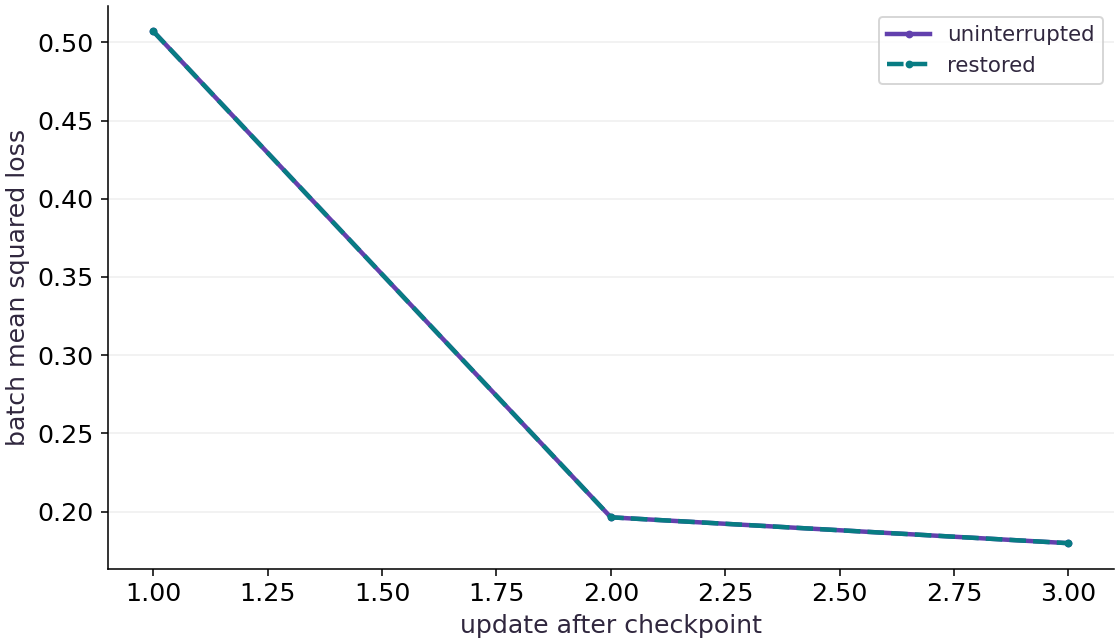

In [10]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal axis counts the three updates after the checkpoint, starting at $1$. The vertical axis is the batch mean squared loss before each update. The uninterrupted and restored lines overlap at about $0.5070$, $0.1964$ and $0.1798$ on the recorded CPU fixture. These are different mini-batches, so the downward sequence should not be interpreted as a full-data convergence guarantee.

### Connect it to the computation

The second plotted update begins a newly shuffled epoch. Its agreement exercises the restored key in addition to the saved order and cursor. The code checks sample IDs and complete state; line overlap alone would not establish those facts. The wrong-key practice deliberately reproduces the first batch and then diverges at the next shuffle. No device throughput or multi-host failure timing is shown.

## Keep weights but discard momentum

Predict: Will restoring the correct weights be enough to reproduce the very next update?

In [11]:
# Experiment — Keep weights but discard momentum: The data stream is correct in this injected failure.
incomplete = {**restored, 'momentum': placed(np.zeros(width, np.float32))}
# Run `transition` to compute `(wrong_next, wrong_ids, _)`.
wrong_next, wrong_ids, _ = transition(incomplete)
# Run `transition` to compute `(right_next, right_ids, _)`.
right_next, right_ids, _ = transition(restored)
# Execute `np.testing.assert_array_equal(wrong_ids, right_ids)`
np.testing.assert_array_equal(wrong_ids, right_ids)
# Aggregate array values to compute `weight_gap`.
weight_gap = float(np.max(np.abs(np.asarray(wrong_next['weights']) - np.asarray(right_next['weights']))))
# Assert invariant `weight_gap > 1e-5` holds
assert weight_gap > 1e-5
# Print the observed values to compare against the expected result.
print('Same next sample IDs, different weights after missing momentum:', weight_gap)

Same next sample IDs, different weights after missing momentum: 0.0195157527923584


Expected: The next sample IDs match but the updated weights differ.

The data stream is correct in this injected failure. The missing optimizer memory explains the different update, so restarting the data loader would not repair it.

## Your exercise

Extend uninterrupted and restored execution by two additional steps. Verify sample IDs, complete state and every local parameter replica. Explain which comparison would fail if a single replica held a different parameter vector.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.

**Step-by-step implementation plan:**
1. Run `transition` to compute `(baseline, ids_a, _)`.
2. Run `transition` to compute `(resumed, ids_b, _)`.
3. Execute `np.testing.assert_array_equal(ids_a, ids_b)`
4. Loop over `name` in `baseline`:
5. Convert `` to a host NumPy array for inspection or verification.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Extend uninterrupted and restored execution by two additional steps.
for _ in range(2):
    # Run `transition` to compute `(baseline, ids_a, _)`.
    baseline, ids_a, _ = transition(...)  # TODO: compute baseline, ids_a, _
    # Run `transition` to compute `(resumed, ids_b, _)`.
    resumed, ids_b, _ = transition(...)  # TODO: compute resumed, ids_b, _
    # Execute `np.testing.assert_array_equal(ids_a, ids_b)`
    np.testing.assert_array_equal(ids_a, ids_b)
    # Loop over `name` in `baseline`:
    for name in baseline:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol
    # Loop over `shard` in `resumed['weights'].addressable_shards`:
    for shard in resumed['weights'].addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(shard.data), np.asarray(baseline['weights']), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(shard.data), np.asarray(baseline['weights']), rtol
# Assert invariant `int(resumed['step']) == 6` holds
assert int(resumed['step'])  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Five resumed transitions and all addressable parameter replicas agree.')
```

In [12]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Extend uninterrupted and restored execution by two additional steps.
# for _ in range(2):
    # Run `transition` to compute `(baseline, ids_a, _)`.
#     baseline, ids_a, _ = transition(...)  # TODO: compute baseline, ids_a, _
    # Run `transition` to compute `(resumed, ids_b, _)`.
#     resumed, ids_b, _ = transition(...)  # TODO: compute resumed, ids_b, _
    # Execute `np.testing.assert_array_equal(ids_a, ids_b)`
#     np.testing.assert_array_equal(ids_a, ids_b)
    # Loop over `name` in `baseline`:
#     for name in baseline:
        # Convert `` to a host NumPy array for inspection or verification.
#         np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol
    # Loop over `shard` in `resumed['weights'].addressable_shards`:
#     for shard in resumed['weights'].addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
#         np.testing.assert_allclose(np.asarray(shard.data), np.asarray(baseline['weights']), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(shard.data), np.asarray(baseline['weights']), rtol
# Assert invariant `int(resumed['step']) == 6` holds
# assert int(resumed['step'])  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Five resumed transitions and all addressable parameter replicas agree.')

## Reference solution

Try your own implementation first.

In [13]:
# Exercise solution: Extend uninterrupted and restored execution by two additional steps.
for _ in range(2):
    # Run `transition` to compute `(baseline, ids_a, _)`.
    baseline, ids_a, _ = transition(baseline)
    # Run `transition` to compute `(resumed, ids_b, _)`.
    resumed, ids_b, _ = transition(resumed)
    # Execute `np.testing.assert_array_equal(ids_a, ids_b)`
    np.testing.assert_array_equal(ids_a, ids_b)
    # Loop over `name` in `baseline`:
    for name in baseline:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(baseline[name]), np.asarray(resumed[name]), rtol=2e-5, atol=2e-6)
    # Loop over `shard` in `resumed['weights'].addressable_shards`:
    for shard in resumed['weights'].addressable_shards:
        # Convert `` to a host NumPy array for inspection or verification.
        np.testing.assert_allclose(np.asarray(shard.data), np.asarray(baseline['weights']), rtol=2e-5, atol=2e-6)
# Assert invariant `int(resumed['step']) == 6` holds
assert int(resumed['step']) == 6
# Print the observed values to compare against the expected result.
print('Five resumed transitions and all addressable parameter replicas agree.')

Five resumed transitions and all addressable parameter replicas agree.


## Find a delayed random-state failure · Transfer

Restore the saved order and cursor but replace the saved key with a different key. Compare the first resumed batch and the following epoch’s first batch. Predict where replay will first fail.

Hint: The saved order supplies the remaining current-epoch batch. The key is consumed when the next permutation is generated.

### How to write: Find a delayed random-state failure — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `jnp.allclose(actual, expected, rtol=..., atol=...)` — Checks that two arrays match elementwise within floating-point tolerance.
- `jax.random.PRNGKey(seed) & jax.random.split(key)` — Manages explicit, stateless PRNG keys—always split a key before passing subkeys into independent random draws.

**Step-by-step implementation plan:**
1. Create or split explicit PRNG key(s) (`wrong_key_state`) for reproducible randomness.
2. Run `transition` to compute `(correct_a, ids_a, _)`.
3. Run `transition` to compute `(wrong_a, ids_b, _)`.
4. Execute `np.testing.assert_array_equal(ids_a, ids_b)`
5. Convert `` to a host NumPy array for inspection or verification.

**Starter code scaffold (fill in the TODOs):**

```python
# Find a delayed random-state failure (Transfer): A successful first resumed update is separate from future...
# Create or split explicit PRNG key(s) (`wrong_key_state`) for reproducible randomness.
wrong_key_state = ...  # TODO: compute wrong_key_state
# Run `transition` to compute `(correct_a, ids_a, _)`.
correct_a, ids_a, _ = transition(...)  # TODO: compute correct_a, ids_a, _
# Run `transition` to compute `(wrong_a, ids_b, _)`.
wrong_a, ids_b, _ = transition(...)  # TODO: compute wrong_a, ids_b, _
# Execute `np.testing.assert_array_equal(ids_a, ids_b)`
np.testing.assert_array_equal(ids_a, ids_b)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(correct_a['weights']), np.asarray(wrong_a['weights']), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(correct_a['weights']), np.asarray(wrong_a['weights']), rtol
# Run `transition` to compute `(correct_b, ids_c, _)`.
correct_b, ids_c, _ = transition(...)  # TODO: compute correct_b, ids_c, _
# Run `transition` to compute `(wrong_b, ids_d, _)`.
wrong_b, ids_d, _ = transition(...)  # TODO: compute wrong_b, ids_d, _
# Assert invariant `not np.array_equal(ids_c, ids_d)` holds
assert not np.array_equal(ids_c, ids_d)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Current-epoch batch matches; next-epoch batch exposes the wrong key.')
```

In [14]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Find a delayed random-state failure (Transfer): A successful first resumed update is separate from future...
# Create or split explicit PRNG key(s) (`wrong_key_state`) for reproducible randomness.
# wrong_key_state = ...  # TODO: compute wrong_key_state
# Run `transition` to compute `(correct_a, ids_a, _)`.
# correct_a, ids_a, _ = transition(...)  # TODO: compute correct_a, ids_a, _
# Run `transition` to compute `(wrong_a, ids_b, _)`.
# wrong_a, ids_b, _ = transition(...)  # TODO: compute wrong_a, ids_b, _
# Execute `np.testing.assert_array_equal(ids_a, ids_b)`
# np.testing.assert_array_equal(ids_a, ids_b)
# Convert `` to a host NumPy array for inspection or verification.
# np.testing.assert_allclose(np.asarray(correct_a['weights']), np.asarray(wrong_a['weights']), rtol = ...  # TODO: compute np.testing.assert_allclose(np.asarray(correct_a['weights']), np.asarray(wrong_a['weights']), rtol
# Run `transition` to compute `(correct_b, ids_c, _)`.
# correct_b, ids_c, _ = transition(...)  # TODO: compute correct_b, ids_c, _
# Run `transition` to compute `(wrong_b, ids_d, _)`.
# wrong_b, ids_d, _ = transition(...)  # TODO: compute wrong_b, ids_d, _
# Assert invariant `not np.array_equal(ids_c, ids_d)` holds
# assert not np.array_equal(ids_c, ids_d)  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Current-epoch batch matches; next-epoch batch exposes the wrong key.')

## Reference reasoning

A successful first resumed update is separate from future replay when later branches consume state that was not yet used. Crossing the epoch boundary reveals the changed key.

In [15]:
# Find a delayed random-state failure (Transfer): A successful first resumed update is separate from future...
# Create or split explicit PRNG key(s) (`wrong_key_state`) for reproducible randomness.
wrong_key_state = {**restored, 'key': placed(np.asarray(jax.random.PRNGKey(999)))}
# Run `transition` to compute `(correct_a, ids_a, _)`.
correct_a, ids_a, _ = transition(restored)
# Run `transition` to compute `(wrong_a, ids_b, _)`.
wrong_a, ids_b, _ = transition(wrong_key_state)
# Execute `np.testing.assert_array_equal(ids_a, ids_b)`
np.testing.assert_array_equal(ids_a, ids_b)
# Convert `` to a host NumPy array for inspection or verification.
np.testing.assert_allclose(np.asarray(correct_a['weights']), np.asarray(wrong_a['weights']), rtol=2e-5, atol=2e-6)
# Run `transition` to compute `(correct_b, ids_c, _)`.
correct_b, ids_c, _ = transition(correct_a)
# Run `transition` to compute `(wrong_b, ids_d, _)`.
wrong_b, ids_d, _ = transition(wrong_a)
# Assert invariant `not np.array_equal(ids_c, ids_d)` holds
assert not np.array_equal(ids_c, ids_d)
# Print the observed values to compare against the expected result.
print('Current-epoch batch matches; next-epoch batch exposes the wrong key.')

Current-epoch batch matches; next-epoch batch exposes the wrong key.


## Checkpoint

The first resumed batch and update match, but sample IDs differ at the next epoch. Which saved value should you inspect first?

1. Only the learning-rate constant.
2. The random key used to construct the next permutation.
3. The display formatting of the loss.

## Diagnose

Matching IDs with differing weights suggests parameter or optimizer-state mismatch. Differing IDs suggests order, cursor, data identity or shuffle-key mismatch. On multiple hosts also inspect consistent configuration, shared checkpoint access and collective call order; a local CPU pass is distinct from those conditions.

## Evidence

Keep the checkpoint path, saved/restored full state, subsequent sample IDs and losses through a new epoch. Diagnose missing momentum and a changed shuffle key; state the untested multi-host boundary.

## Carry forward

- Restore parameters, optimizer, random and input-position state together.
- Compare more than one resumed update and cross a state-consuming boundary.
- Keep single-host correctness evidence separate from multi-host fault-tolerance evidence.

## Primary references

- [Orbax checkpointing](https://orbax.readthedocs.io/en/latest/guides/checkpoint/orbax_checkpoint_101.html)
- [JAX multi-controller execution](https://docs.jax.dev/en/latest/multi_process.html)
- [JAX distributed data loading](https://docs.jax.dev/en/latest/distributed_data_loading.html)